In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler

# 1. Загрузка
df = pd.read_csv("texas.csv")

# 2. Подготовка
treated_fip = 48
treated = df[df["statefip"] == treated_fip].copy()
donors = df[(df["statefip"] != treated_fip) & (df["statefip"] >= 1)].copy()

pre_years = list(range(1985, 1993))
post_years = list(range(1993, 2001))
predictors = ["poverty", "income", "alcohol", "aidscapita", "black", "perc1519"]

In [46]:
# ========== 3. ЖЁСТКАЯ ФИЛЬТРАЦИЯ ДОНОРОВ ==========
print("=== ДО ФИЛЬТРАЦИИ ===")
print(f"Доноров: {donors['statefip'].nunique()}")

donors_filtered = donors.copy()

# 3.1 Исключаем штаты с bmprison < 10000 (слишком низкие)
low_prison = donors_filtered[donors_filtered["year"].isin(pre_years)] \
    .groupby("statefip")["bmprison"].mean()
low_prison = low_prison[low_prison < 10000].index.tolist()
donors_filtered = donors_filtered[~donors_filtered["statefip"].isin(low_prison)]
print(f"Исключено с bmprison < 10000: {low_prison}")

# 3.2 Исключаем штаты с black < 10% (слишком мало черного населения)
low_black = donors_filtered[donors_filtered["year"].isin(pre_years)] \
    .groupby("statefip")["black"].mean()
low_black = low_black[low_black < 10].index.tolist()
donors_filtered = donors_filtered[~donors_filtered["statefip"].isin(low_black)]
print(f"Исключено с black < 10%: {low_black}")

# 3.3 Оставляем только штаты с bmprison между 10000 и 30000
bmprison_means = donors_filtered[donors_filtered["year"].isin(pre_years)] \
    .groupby("statefip")["bmprison"].mean()
bmprison_means = bmprison_means[(bmprison_means >= 10000) & (bmprison_means <= 30000)]
donors_filtered = donors_filtered[donors_filtered["statefip"].isin(bmprison_means.index)]

# 3.4 Исключаем DC (statefip 11) - экстремально высокий СПИД и black%
if 11 in donors_filtered["statefip"].values:
    donors_filtered = donors_filtered[donors_filtered["statefip"] != 11]
    print("Исключён DC (statefip=11)")

print(f"\n=== ПОСЛЕ ФИЛЬТРАЦИИ ===")
print(f"Доноров: {donors_filtered['statefip'].nunique()}")
print(f"Оставшиеся штаты: {sorted(donors_filtered['statefip'].unique())}")

=== ДО ФИЛЬТРАЦИИ ===
Доноров: 50
Исключено с bmprison < 10000: [1.0, 2.0, 4.0, 5.0, 8.0, 9.0, 10.0, 11.0, 15.0, 16.0, 18.0, 19.0, 20.0, 21.0, 23.0, 25.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 35.0, 37.0, 38.0, 40.0, 41.0, 44.0, 45.0, 46.0, 47.0, 49.0, 50.0, 51.0, 53.0, 54.0, 55.0, 56.0]
Исключено с black < 10%: [42.0]

=== ПОСЛЕ ФИЛЬТРАЦИИ ===
Доноров: 10
Оставшиеся штаты: [6.0, 12.0, 13.0, 17.0, 22.0, 24.0, 26.0, 34.0, 36.0, 39.0]


In [48]:
# ========== 4. Матрица предикторов ==========
X_pre = donors_filtered[donors_filtered["year"].isin(pre_years)].groupby("statefip")[predictors].mean()
X_treated_pre = treated[treated["year"].isin(pre_years)][predictors].mean().values
X_donors = X_pre.values
donor_fips = X_pre.index.values
# 5. Нормализация
scaler = StandardScaler()
X_donors_scaled = scaler.fit_transform(X_donors)
X_treated_scaled = scaler.transform([X_treated_pre])[0]

# 6. Оптимизация
def loss(w, X_donors, X_treated):
    synthetic = np.dot(w, X_donors)
    return np.sum((X_treated - synthetic) ** 2)

def constraint(w):
    return np.sum(w) - 1.0

n_donors = X_donors.shape[0]
bounds = [(0, 1)] * n_donors
constraints = [{"type": "eq", "fun": constraint}]
w0 = np.ones(n_donors) / n_donors

result = minimize(loss, w0, args=(X_donors_scaled, X_treated_scaled),
                  bounds=bounds, constraints=constraints, method="SLSQP",
                  options={'maxiter': 1000})

weights = result.x

print(f"\nОптимизация: {result.success}")
print(f"Сумма весов: {np.sum(weights):.10f}")


Оптимизация: True
Сумма весов: 1.0000000000


In [50]:
# 7. Веса доноров
weight_df = pd.DataFrame({"statefip": donor_fips, "weight": weights})
weight_df = weight_df.sort_values("weight", ascending=False)

print("\n=== ВЕСА ДОНОРНЫХ ШТАТОВ ===")
print(weight_df[weight_df["weight"] > 0.01].round(4))

# 8. Синтетическая траектория
bmprison_donors = donors_filtered.pivot(index="statefip", columns="year", values="bmprison")
all_years = sorted(df["year"].unique())
bmprison_donors = bmprison_donors.reindex(columns=all_years)

synthetic_bmprison = np.dot(weights, bmprison_donors.values)
actual_bmprison = treated.set_index("year").reindex(all_years)["bmprison"].values
years_all = np.array(all_years)


=== ВЕСА ДОНОРНЫХ ШТАТОВ ===
   statefip  weight
4      22.0  0.3666
0       6.0  0.2712
6      26.0  0.2257
9      39.0  0.1365


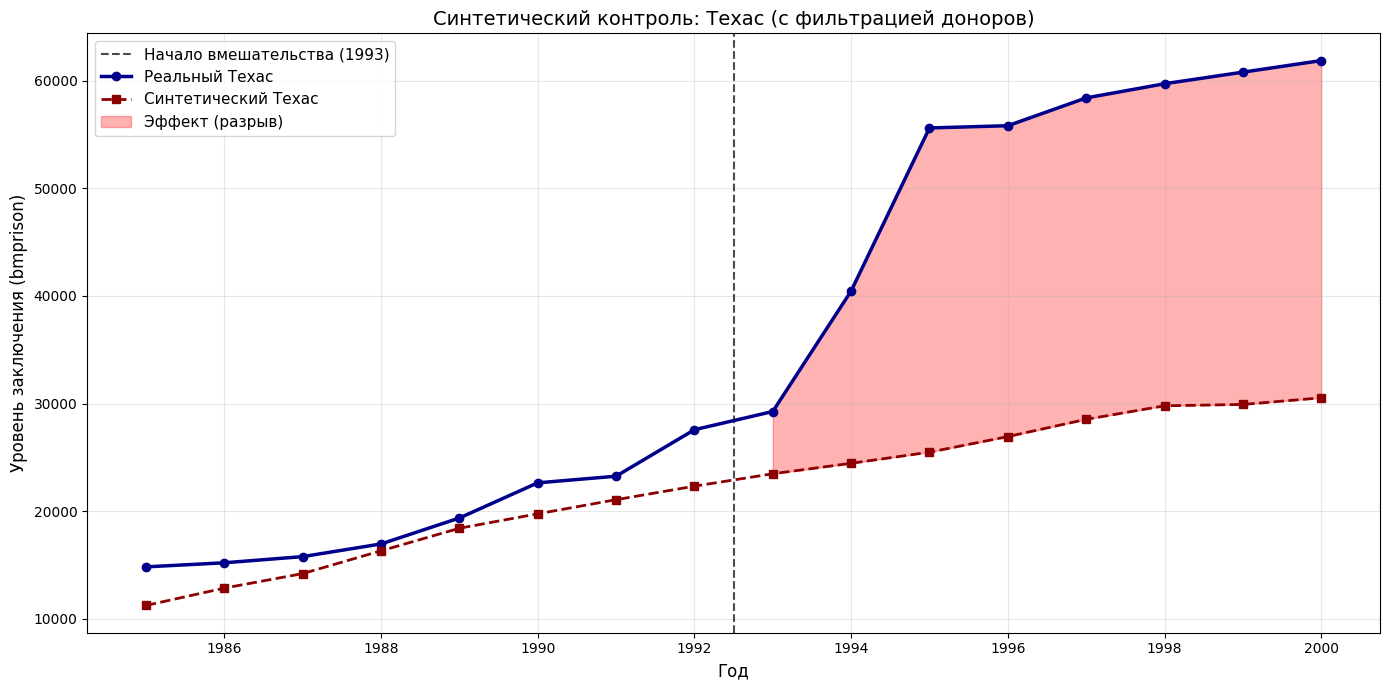

In [52]:
# 9. ГРАФИК
plt.figure(figsize=(14, 7))
plt.axvline(x=1992.5, color="black", linestyle="--", label="Начало вмешательства (1993)", alpha=0.7)
plt.plot(years_all, actual_bmprison, label="Реальный Техас", linewidth=2.5, color="darkblue", marker='o')
plt.plot(years_all, synthetic_bmprison, label="Синтетический Техас", linestyle="--", 
         linewidth=2, color="darkred", marker='s')

# Закрашиваем эффект после 1993
post_mask = years_all >= 1993
plt.fill_between(years_all[post_mask], 
                 actual_bmprison[post_mask], 
                 synthetic_bmprison[post_mask], 
                 alpha=0.3, color="red", label="Эффект (разрыв)")

plt.xlabel("Год", fontsize=12)
plt.ylabel("Уровень заключения (bmprison)", fontsize=12)
plt.title("Синтетический контроль: Техас (с фильтрацией доноров)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# 10. Баланс предикторов
synthetic_pre = np.dot(weights, X_donors)
balance = pd.DataFrame({
    "Предиктор": predictors,
    "Реальный Техас": X_treated_pre,
    "Синтетический Техас": synthetic_pre,
    "Абс. ошибка": np.abs(X_treated_pre - synthetic_pre),
    "Отн. ошибка (%)": np.abs((X_treated_pre - synthetic_pre) / X_treated_pre * 100)
})
print("\n=== БАЛАНС ПРЕДИКТОРОВ ===")
print(balance.round(2))


=== БАЛАНС ПРЕДИКТОРОВ ===
    Предиктор  Реальный Техас  Синтетический Техас  Абс. ошибка  \
0     poverty           17.20                16.66         0.54   
1      income        16108.62             16791.37       682.74   
2     alcohol            2.51                 2.50         0.01   
3  aidscapita           10.05                 8.38         1.67   
4       black           16.02                19.50         3.48   
5    perc1519            7.88                 7.69         0.19   

   Отн. ошибка (%)  
0             3.16  
1             4.24  
2             0.51  
3            16.57  
4            21.72  
5             2.38  


In [56]:
# 11. MSPE
pre_mask = np.isin(years_all, pre_years)
mspe_pre = np.mean((actual_bmprison[pre_mask] - synthetic_bmprison[pre_mask]) ** 2)
print(f"\nMSPE в донорный период: {mspe_pre:.2f}")

post_mask = np.isin(years_all, post_years)
mspe_post = np.mean((actual_bmprison[post_mask] - synthetic_bmprison[post_mask]) ** 2)
print(f"MSPE в пост-период: {mspe_post:.2f}")
print(f"Отношение (post/pre): {mspe_post/mspe_pre:.2f}")


MSPE в донорный период: 7844321.93
MSPE в пост-период: 718992178.19
Отношение (post/pre): 91.66
